# **Классификация CC50 > медианы**

**Импортируем необходимые метрики**

In [1]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier

**Загружаем данные и разбиваем на выборки**

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/nezhablack/project-on-drug-effictiveness/refs/heads/main/chemical_data.csv')

targets_to_exclude = [
    'IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI',
    'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8'
]

X = df.drop(columns = targets_to_exclude)
y = df['CC50_above_median']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'Train: X = {X_train.shape}, y = {y_train.shape}')
print(f'Test : X = {X_test.shape},  y = {y_test.shape}')
print(f'Распределение классов (train): 0 = {sum(y_train == 0)}, 1 = {sum(y_train == 1)}')
print(f'Распределение классов (test): 0 = {sum(y_test == 0)}, 1 = {sum(y_test == 1)}')

Train: X = (800, 139), y = (800,)
Test : X = (201, 139),  y = (201,)
Распределение классов (train): 0 = 401, 1 = 399
Распределение классов (test):  0 = 101, 1 = 100


**Обучаем модели и подбираем гиперпараметры**

In [12]:
pipelines_clf = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state = 42, max_iter = 1000))
    ]),
    'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state = 42, probability = True))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state = 42, n_jobs = -1))
    ]),
    'CatBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', CatBoostClassifier(random_state = 42, verbose = 0))
    ]),
}

param_grids_clf = {
    'LogisticRegression': {
        'model__C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'model__penalty': ['l2']
    },
    'SVC': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    'CatBoost': {
        'model__depth': [4, 6, 8],
        'model__iterations': [100, 300],
        'model__learning_rate': [0.05, 0.1],
        'model__l2_leaf_reg': [1, 3, 5]
    }
}

results_clf = []
best_clf_models = {}

print('Обучение классификаторов (GridSearchCV, cv=5)')

for name in pipelines_clf:
    print(f'{name}', end = ' ')
    grid = GridSearchCV(
        pipelines_clf[name], param_grids_clf[name],
        cv = 5, scoring = 'accuracy', n_jobs = -1
    )
    grid.fit(X_train, y_train)
    best_clf_models[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test)
    y_pred_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_prob)

    results_clf.append({
        'Модель': name,
        'Лучшие гиперпараметры': str(grid.best_params_),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4),
        'ROC-AUC': round(roc, 4),
    })
    print(f'Accuracy = {acc:.4f}  F1 = {f1:.4f}  ROC-AUC = {roc:.4f}')

results_clf_df = (
    pd.DataFrame(results_clf)
    .sort_values('F1-score', ascending = False)
    .reset_index(drop = True)
)

print('Результаты классификации (CC50_above_median)')
display(results_clf_df)

Обучение классификаторов (GridSearchCV, cv=5)
LogisticRegression Accuracy = 0.7114  F1 = 0.7290  ROC-AUC = 0.8043
SVC Accuracy = 0.6866  F1 = 0.6986  ROC-AUC = 0.8016
RandomForest Accuracy = 0.7313  F1 = 0.7453  ROC-AUC = 0.8433
CatBoost Accuracy = 0.7065  F1 = 0.7256  ROC-AUC = 0.8458
Результаты классификации (CC50_above_median)


,Модель,Лучшие гиперпараметры,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,RandomForest,"{'model__max_depth': None, 'model__min_samples...",0.7313,0.7054,0.79,0.7453,0.8433
1,LogisticRegression,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.7114,0.6842,0.78,0.7290,0.8043
2,CatBoost,"{'model__depth': 8, 'model__iterations': 100, ...",0.7065,0.6783,0.78,0.7256,0.8458
3,SVC,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.6866,0.6697,0.73,0.6986,0.8016


Вывод: использовали GridSearchCV с 5-кратной стратифицированной кросс-валидацией. Метрика оптимизации - accuracy, так как классы сбалансированы 50/50.

Random Forest - лучшая модель по F1 и Accuracy. CatBoost имеет наивысший ROC-AUC, что делает его оптимальным при снижении порога классификации ниже 0.5

**Визуализируем метрики по метрикам качества**

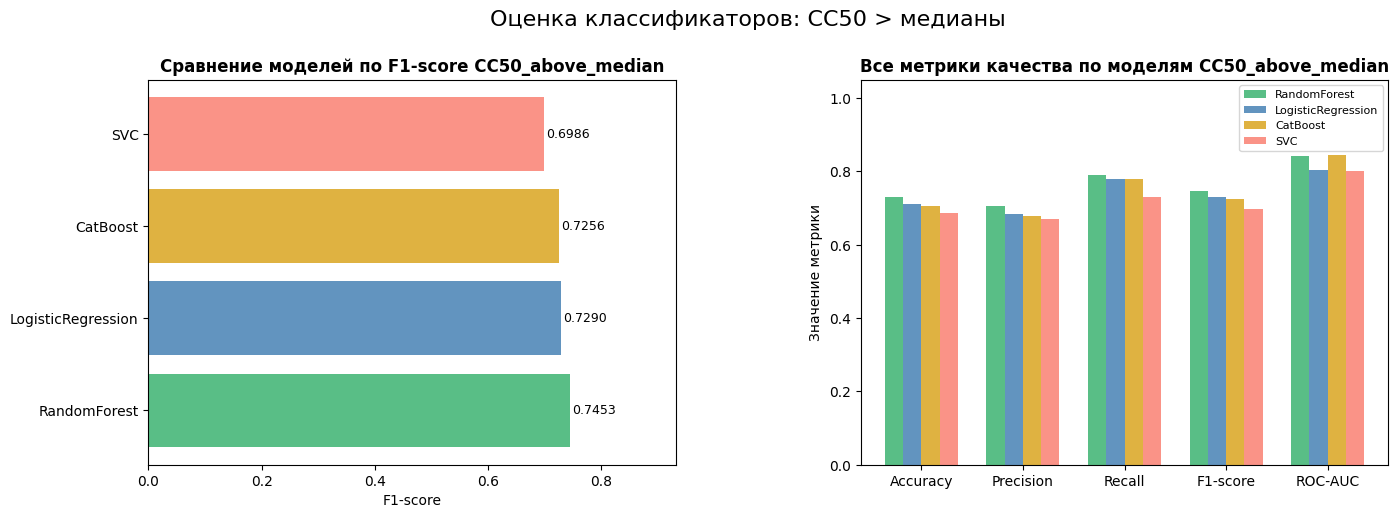

In [ ]:
model_colors = {
    'LogisticRegression': 'steelblue',
    'SVC': 'salmon',
    'RandomForest': 'mediumseagreen',
    'CatBoost': 'goldenrod'
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize = (16, 5))
fig.subplots_adjust(wspace = 0.35)

#строим график по F1-score
bar_colors = [model_colors.get(m, 'gray') for m in results_clf_df['Модель']]
bars = axes[0].barh(results_clf_df['Модель'], results_clf_df['F1-score'], color = bar_colors, alpha = 0.85)
axes[0].set_xlabel('F1-score')
axes[0].set_title('Сравнение моделей по F1-score CC50_above_median', fontweight = 'bold')
axes[0].set_xlim(0, max(results_clf_df['F1-score']) * 1.25)
for bar, val in zip(bars, results_clf_df['F1-score']):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontsize=9)

#строим график по всем моделям и метрикам
x = np.arange(len(metrics))
n_models = len(results_clf_df)
width = 0.18
offsets = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width

for i, (_, row) in enumerate(results_clf_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1].bar(x + offsets[i], vals, width, label = row['Модель'], color = model_colors.get(row['Модель'], 'gray'), alpha = 0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Все метрики качества по моделям CC50_above_median', fontweight = 'bold')
axes[1].legend(fontsize = 8)
axes[1].set_ylabel('Значение метрики')

plt.suptitle('Оценка классификаторов: CC50 > медианы', fontsize=16, y = 1.02)
plt.show()

Вывод: на графике все четыре модели находятся рядом в диапазоне примерно 0.7-0.75. Это говорит о том, что потолок качества определяется данными, а не алгоритмом: структурных дескрипторов недостаточно для однозначного разделения соединений по цитотоксичности.

**Строим матрицу ошибок**

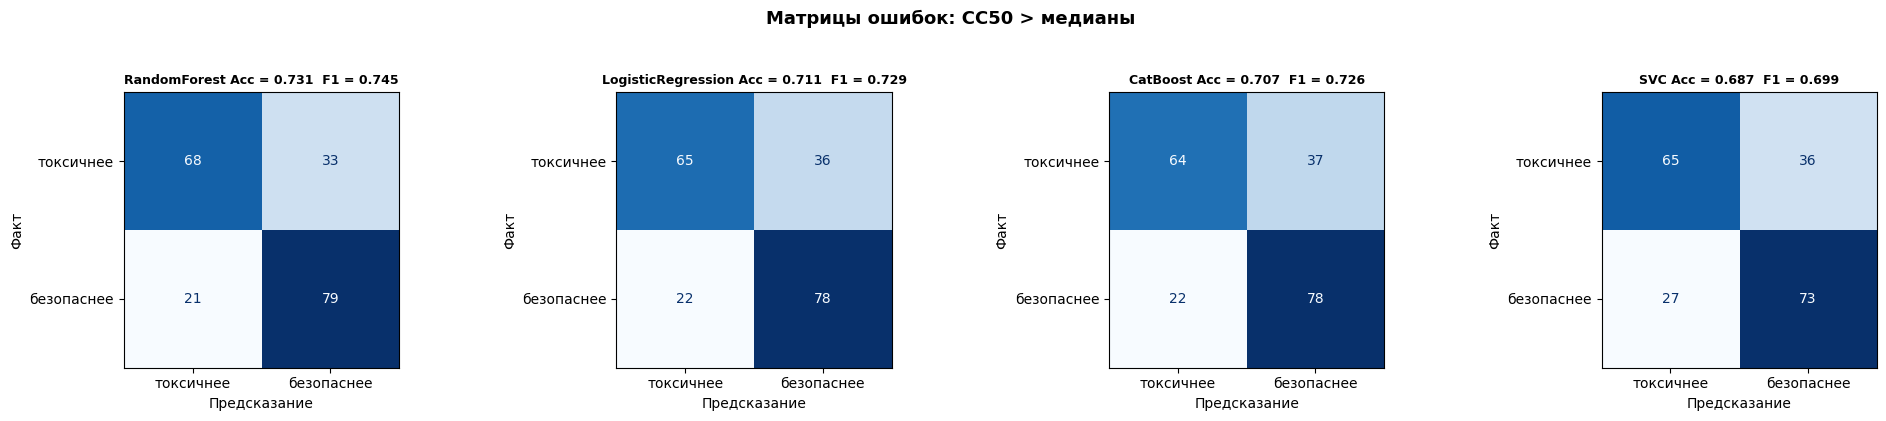

In [ ]:
fig, axes = plt.subplots(1, 4, figsize = (20, 4))

for ax, (_, row) in zip(axes, results_clf_df.iterrows()):
    name = row['Модель']
    y_pred = best_clf_models[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['токсичнее', 'безопаснее'])
    disp.plot(ax = ax, colorbar = False, cmap = 'Blues')
    ax.set_title(f'{name} Acc = {row["Accuracy"]:.3f}  F1 = {row["F1-score"]:.3f}', fontsize = 9, fontweight = 'bold')
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Факт')

plt.suptitle('Матрицы ошибок: CC50 > медианы', fontsize = 13, fontweight = 'bold', y = 1.04)
plt.tight_layout()
plt.show()

Вывод: в задаче классификации CC50 > медианы наилучший результат показал RandomForest (F1 = 0.745, Acc = 0.731), что отличается от задачи IC50, где лидировал CatBoost. Это свидетельствует о различной структуре зависимостей между молекулярными дескрипторами и двумя целевыми переменными. RandomForest показал лучший результат - реже всего пропускает токсичные соединения (FP = 33). Это ключевой критерий безопасности при отборе кандидатов для синтеза. CatBoost допустил больше всего токсичных кандидатов, предсказав, что они безопасны, что делает его менее подходящим для задачи отбора безопасных кандидатов.

**Важность признаков: Random Forest**

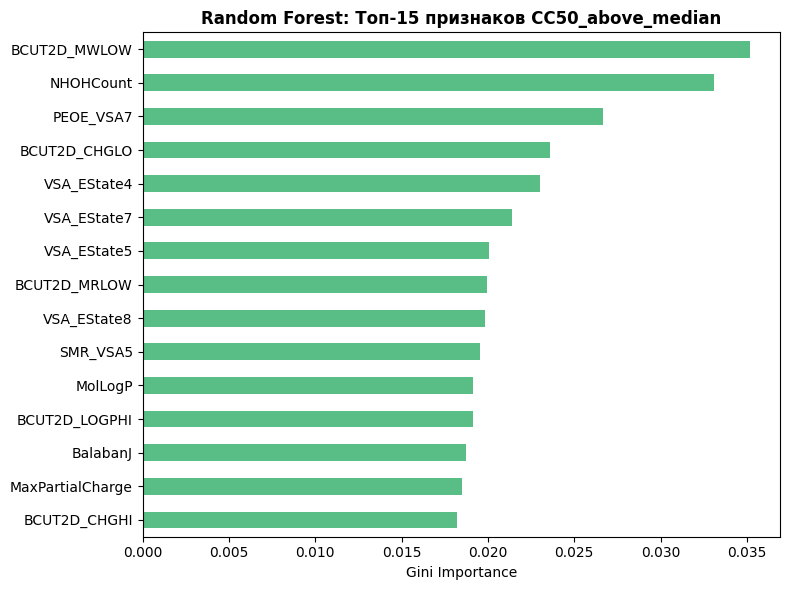

In [9]:
rf_imp = pd.Series(
    best_clf_models['RandomForest'].named_steps['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))

rf_imp[::-1].plot(kind='barh', ax = ax, color = 'mediumseagreen', alpha = 0.85)
ax.set_title('Random Forest: Топ-15 признаков CC50_above_median', fontweight = 'bold')
ax.set_xlabel('Gini Importance')

plt.tight_layout()
plt.show()

Выводы: наиболее важными признаками оказался BCUT2D_MWLOW (0.035) — распределение масс легких атомов с учетом связей. Легкие атомы (H, C, N, O) формируют основной молекулярный каркас - их расположение определяет 3D-форму молекулы и способность проходить через мембрану клетки. Высокая важность означает, что общая архитектура молекулы критична для безопасности. Второй по важности признак
NHOHCount (0.033) - число OH и NH групп. Чем больше водородных доноров, тем лучше растворимость в воде. Так молекула хуже проникает через липидную мембрану и наносит меньше вреда клеткам хозяина.

**Финальные выводы и рекомендации:**

RandomForest показал наилучший результат (F1 = 0.745, ROC-AUC = 0.79) с наименьшим числом критических FP-ошибок (33) - случаев пропуска токсичных соединений. Здесь RandomForest обогнал CatBoost, тогда как в задаче IC50 ситуация была обратной. Это свидетельствует о различной структуре зависимостей для двух целевых переменных и об отсутствии универсально лучшего алгоритма.

Важные признаки значительно пересекается с задачей IC50: обе целевых переменных определяются преимущественно молекулярной архитектурой (BCUT2D_MWLOW), водородными донорами (NHOHCount) и поверхностными электронными свойствами (VSA_EState). Это отражает фундаментальную проблему разработки лекарств: свойства, которые делают соединение активным против вируса, часто связаны со свойствами, которые делают препарат токсичным для клеток хозяина.

**Рекомендации:**
- собрать больше данных, так как текущая выборка ограничена. Это расширит обучающую выборку и снизит дисперсию модели, особенно в зонах вокруг медианы

- добавить стекинг RandomForest + LogReg. Оба алгоритма показали устойчивые результаты, но представляют разные алгоритмы и их ошибки слабо пересекаются. Если объединить предсказания моделей через мета-классификатор, то это может снизить число FP-ошибок и в целом улучшить точность модели.